In [ ]:
import numpy as np
from pyproj import Geod, Transformer
import matplotlib.pyplot as plt

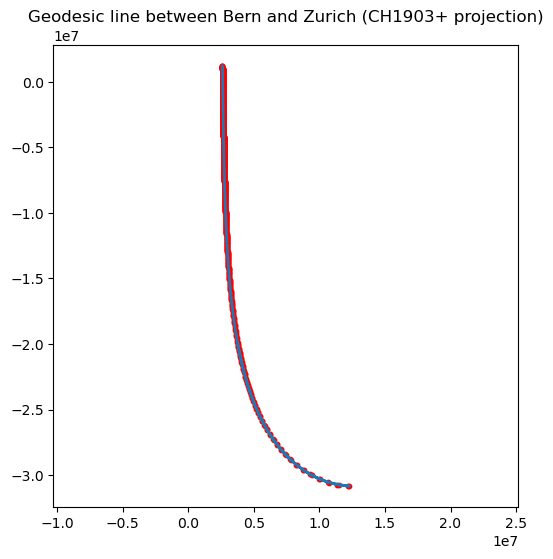

In [13]:
lat1, lon1 = 46.948, 7.447   # Bern
lat2, lon2 = -47.376, 8.541   # Zurich

geod = Geod(ellps="WGS84")
n = 1000
points = geod.npts(lon1, lat1, lon2, lat2, n)
lons, lats = zip(*points)
lons = [lon1] + list(lons) + [lon2]
lats = [lat1] + list(lats) + [lat2]

transformer = Transformer.from_crs("EPSG:4326", "EPSG:2056", always_xy=True)
x, y = transformer.transform(lons, lats)

plt.figure(figsize=(6, 6))
plt.plot(x, y, '-', lw=2)
plt.scatter(x, y, c='red', s=10)
plt.title("Geodesic line between Bern and Zurich (CH1903+ projection)")
plt.axis('equal')
plt.show()